# Fitting example RUBIES-UDS31 154183: "The Cliff"

Fits two dispersers (PRISM + G395M) for The Cliff (de Graaff+25) at z~3.55 source using
various continuum models.

Lines: Hα, Hβ, [OIII], Paγ, Paδ, HeI 10833                                                                                                                                     

### Notes
* Make sure to install unite with the editable flag.
* Unite will initialize with `JAX_ENABLE_X64=1`. If you need to import jax, do so after unite.

## 0. Check installation

In [1]:
import sys, numpy, scipy
from unite.spectra import NIRSpecSpectra
from unite.fitting import NIRSpecFit
from unite.utils import download_spectra
from dotfit import EmissionLines
import jax, jaxlib  

print(sys.version)
print('numpy:', numpy.__version__)
print('scipy:', scipy.__version__)
print('jax:', jax.__version__)
print('jaxlib:', jaxlib.__version__)
print("jax x64 enabled:", jax.numpy.ones(1).dtype == jax.numpy.float64)
print('Available backends:', jax.devices())

3.13.11 | packaged by conda-forge | (main, Dec  6 2025, 11:28:54) [Clang 19.1.7 ]
numpy: 2.3.5
scipy: 1.16.3
jax: 0.5.0
jaxlib: 0.5.0
jax x64 enabled: True
Available backends: [CpuDevice(id=0)]


## 1. Download and load spectra

The master table already includes these spectra, so no CSV is needed.

In [ ]:
spec_dir = 'spectra'
out_dir = 'out_cliff'

spec_names = [
    'rubies-uds31-v4_prism-clear_4233_154183.spec.fits',
    'rubies-uds31-v4_g395m-f290lp_4233_154183.spec.fits',
]

spec_table = download_spectra(
    spec_names,
    spectra_directory=spec_dir,
)

spectra = NIRSpecSpectra(rows=spec_table)

spec_table['srcid', 'file', 'root', 'grating', 'z_best']

Loading spectra table (cached)


[True, False]

## 2. Configure emission lines

We fit H$\alpha$, H$\beta$, [OIII] doublet, Paschen $\gamma$, Paschen $\epsilon$, and HeI 10833.

In [ ]:

# line configuration 
el = EmissionLines()
groups = [{'name': 'cliff'}]
groups.append({'absorption': 'Ha'})
#groups.append({'emission': 'Ha, PaG', 'additional': 'exponential'})
#groups.append({'emission': 'PaD, Hb, [OIII]-5008*'})  # Note: * loads the multiplet fixed to theoretical values
groups.append({'exponential': 'Ha, PaG'})
groups.append({'emission': 'Ha, PaG, PaD, Hb, [OIII]-5008*'})  # Note: * loads the multiplet fixed to theoretical values
groups.append({'emission': 'HeI-10833'})
config = el.to_unite(groups, save=True) # convert to unite config format and save to file

# various continuum options: polynomials
# config['continuum'] = {'type': 'none'}    # no continuum
# config['continuum'] = {'type': 'linear'}  # default if continuum key is omitted
# config['continuum'] = {'type': 'chebyshev', "order": 5}
config['continuum'] = {'type': 'bernstein', 'degree': 5}   # positive continuum
# config['continuum'] = {'type': 'bspline', 'n_knots': 5, 'degree': 3}

# Blackbodies
# config['continuum'] = {'type': 'blackbody',
#    'temperature': (1000, 30000),   # default (1000, 30000) K
# }
# config['continuum'] = {'type': 'modified_blackbody',
#     'temperature': (1000, 30000),   # default (1000, 30000) K
#     'beta': (-2.0, 2.0),           # default (-2, 2)
# }
# config['continuum'] = {'type': 'attenuated_blackbody',
#     'temperature': (1000, 5000),   # default (1000, 30000) K
#     'tau_v': (0.0, 5.0),           # default (0, 5)
#     'alpha': (-2.5, 2.0),          # default (-2, 0)
#     'lambda_v_micron': 0.55,       # default 0.55 µm
# }

# Three fitting modes
# config['fitting_mode'] = 'lines'      # fit around line regions (default for linear/chebyshev)
# config['fitting_mode'] = 'full'       # fit entire spectrum (default for blackbody models)
config['fitting_mode'] = 'continuum'  # fit everywhere except emission lines
config['Region'] = (3650, 11500)      # restrict wavelength range (Angstrom) rest-frame

config

name cliff


{'Name': 'cliff',
 'Unit': 'Angstrom',
 'Groups': {'absorption1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'absorption',
     'Lines': [{'Wavelength': 6564.632, 'RelStrength': None}]}]},
  'exponential1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'exponential',
     'Lines': [{'Wavelength': 6564.632, 'RelStrength': None},
      {'Wavelength': 10941.082, 'RelStrength': None}]}]},
  'emission1': {'TieRedshift': True,
   'TieDispersion': True,
   'Species': [{'Name': 'HI',
     'LineType': 'emission',
     'Lines': [{'Wavelength': 6564.632, 'RelStrength': None},
      {'Wavelength': 10941.082, 'RelStrength': None},
      {'Wavelength': 10052.123, 'RelStrength': None},
      {'Wavelength': 4862.691, 'RelStrength': None}]},
    {'Name': '[OIII]m1',
     'LineType': 'emission',
     'Lines': [{'Wavelength': 4960.295, 'RelStrength': 0.3351241241660222},
      {'Wavelength': 5008.24, 'Rel

## 3. Run the fit

MCMC sampling with NUTS. Adjust `N` and `num_warmup` for production runs.

In [4]:
#from unite import defaults
#defaults.redshift['absorption'] = (-1*defaults.δz, 1*defaults.δz)
fit_args = {                                                                                                                                                                   
    'N': 100,                                  
    'num_warmup': 100,                                                                                                                                                         
    'backend': 'MCMC',                                                                                                                                                         
    'rescale_errors': False,                                                                                                                                                   
    'verbose': True,
    'model_version': 'v2',
    'rng_seed': 0,
    'nuts_dense_mass': False,
    'nuts_target_accept_prob': 0.7,
    'nuts_max_tree_depth': 8,
}

results = NIRSpecFit(config, spec_table, spectra, out_dir, **fit_args)
results.summary()

sample: 100%|██████████| 200/200 [01:24<00:00,  2.37it/s, 255 steps of size 1.03e-02. acc. prob=0.89]


┌───────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│ Run: cliff                                                                                                        │
│ full mode   100 samples   WAIC=1735.92                                                                            │
│                                                                                                                   │
│ Spectra:  PRISM  1.67–5.22 µm                                                                                     │
│           G395M  2.69–5.23 µm                                                                                     │
│                                                                                                                   │
│ Lines:                     z   (km/s)           flux (1e-20 cgs)      fwhm (km/s)                                 │
│ HI 6564.632 abs       3.5502    (+10)  -579.41 (-121.5

## 4. Plot results

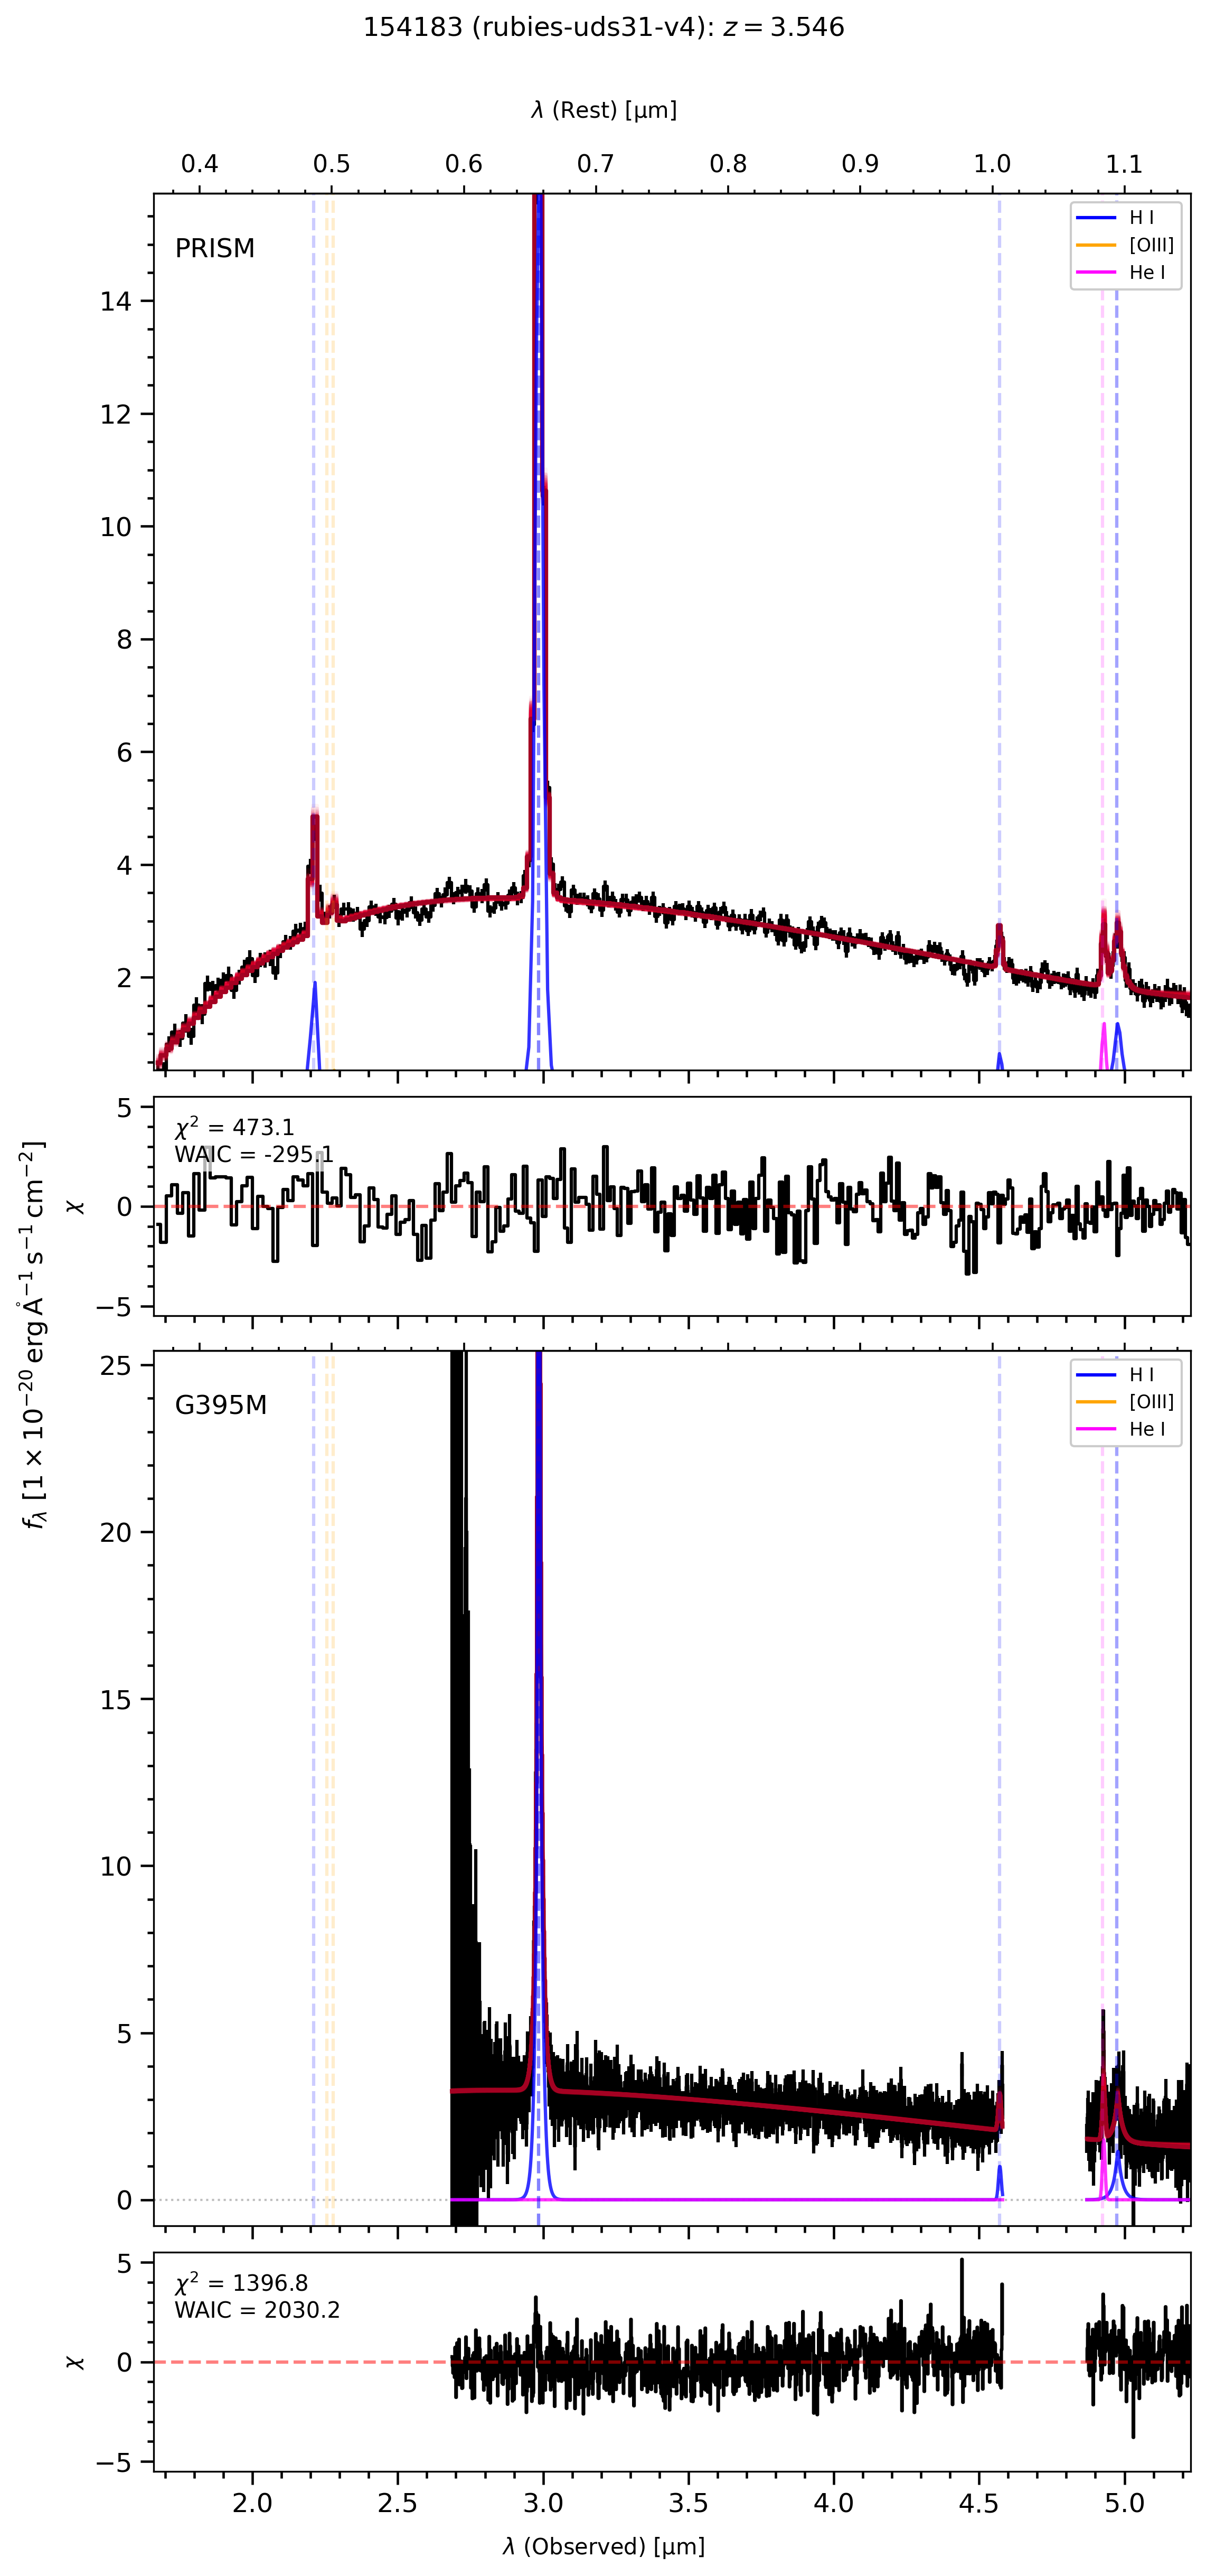

In [5]:
from unite.plotting import plotResults

plot_kw = {'yscale': 'linear', 'show_lines': True}

fig, data = plotResults(
    config, rows=spec_table, output_dir=out_dir,
    plot_kwargs=plot_kw,
)
fig